In [15]:
import numpy as np
try:  
    import cupy as xp  
    USE_GPU = True 
except ImportError:  
    import numpy as xp 
    print('No Cupy')
    USE_GPU = False 

import matplotlib.pyplot as plt
from tqdm import tqdm

# to mute the warnings of lal 
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import * 
from Triangle.GW import * 
from Triangle.TDI import * 

from Triangle_BBH.Waveform import * 
from Triangle_BBH.Response import *
from Triangle_BBH.Utils import *
from Triangle_BBH.Fisher import *

np.random.seed(114515)

# Uncomment this if multiprocessing goes wrong 
# import multiprocessing
# if __name__=='__main__':
#     multiprocessing.set_start_method("fork")

## Initialize time-domain injection 
This is a CPU-only example using the ``WF4PY`` waveform

In [16]:
# run this cell only once 

Tobs = 15. * DAY 
dt = 5. 
tcb_times = np.arange(int(Tobs / dt)) * dt
Tobs = len(tcb_times) * dt   

# orbit model 
orbit = Orbit(OrbitDir="../../Triangle-Simulator/OrbitData/MicroSateOrbitEclipticTCB")

# use Michelson-AET channels 
A2_string, E2_string, T2_string = TDIStringManipulation.AETStringsfromXString(GeneralTDIResponse.X2_strings)

# initialize TDI response
A2_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=A2_string, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000/dt), # drop 100s at the beginning and end to avoid the invalid data caused by TDI calculation 
    linear_interp=False  
    )
E2_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=E2_string, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000/dt), # drop 100s at the beginning and end to avoid the invalid data caused by TDI calculation 
    linear_interp=False  
    )
T2_response_generator = GeneralTDIResponse(
    orbit=orbit, 
    Pstring=T2_string, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=int(1000/dt), # drop 100s at the beginning and end to avoid the invalid data caused by TDI calculation 
    linear_interp=False  
    )

channel_names = ["A2", "E2", "T2"]

## Simulate time-domain waveform 

In [17]:
# generator for the unprojected waveforms. for HM waveform, the consistency can be validated with a mode-by-mode manner. 
mbhb_waveform_generator = MBHB_Injection(approx_method="IMRPhenomD")

In [18]:
# set source parameters 
mbhb_parameters = {
    'chirp_mass': np.power(10., np.random.uniform(5, 7)), # [MSUN]
    'mass_ratio': np.random.uniform(0.1, 1.), 
    'spin_1z': np.random.uniform(-1., 1.),
    'spin_2z': np.random.uniform(-1., 1.),
    'coalescence_time': Tobs / DAY - 3., # [day]
    'coalescence_phase': np.random.uniform(0, TWOPI),
    'luminosity_distance': np.power(10., np.random.uniform(4, 5)), # [MPC]
    'inclination': np.arccos(np.random.uniform(-1., 1.)), # [rad]
    'longitude': np.random.uniform(0, TWOPI), # [rad]
    'latitude': np.arcsin(np.random.uniform(-1., 1.)), # [rad]
    'psi': np.random.uniform(0, PI) # [rad]
    }

td_waveform = np.array([
    A2_response_generator(parameters=mbhb_parameters, waveform_generator=mbhb_waveform_generator), 
    E2_response_generator(parameters=mbhb_parameters, waveform_generator=mbhb_waveform_generator), 
    T2_response_generator(parameters=mbhb_parameters, waveform_generator=mbhb_waveform_generator), 
])

td_waveform = -td_waveform # since our FD response generator uses a different rule for michelson TDI variables 

mbhb_parameters

{'chirp_mass': 113024.62477803571,
 'mass_ratio': 0.338024724135096,
 'spin_1z': 0.055803976312213566,
 'spin_2z': -0.8744231656585615,
 'coalescence_time': 12.0,
 'coalescence_phase': 2.8490028136671177,
 'luminosity_distance': 26844.598730436373,
 'inclination': 2.2326894404081954,
 'longitude': 5.930388193701805,
 'latitude': -0.15421841762076743,
 'psi': 0.5126090238342521}

(11.97, 12.03)

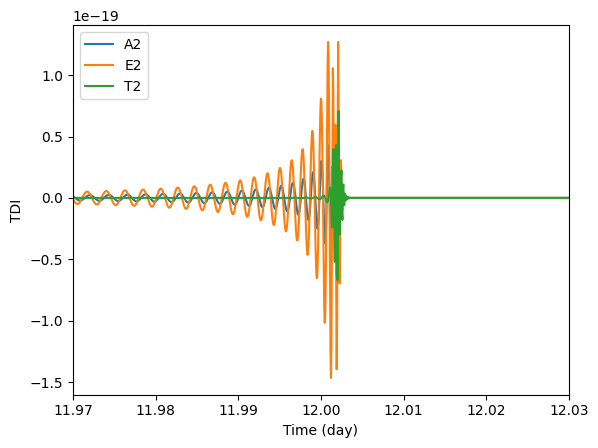

In [19]:
for ich, nch in enumerate(channel_names):
    plt.plot(tcb_times/DAY, td_waveform[ich], label=nch)
plt.xlabel("Time (day)")
plt.ylabel("TDI")
plt.legend(loc="upper left")
plt.xlim(mbhb_parameters["coalescence_time"] - 0.03, mbhb_parameters["coalescence_time"] + 0.03)

## Fourier transform 

In [20]:
fd_waveform_from_td = [] 
for i in range(td_waveform.shape[0]): 
    ff, xf = FFT_window(td_waveform[i], 1./dt) 
    fd_waveform_from_td.append(xf)
fd_waveform_from_td = np.array(fd_waveform_from_td)

frequencies = ff 

# get rid of null frequencies 
mask = np.ones_like(frequencies, dtype=bool)
for i in range(40):
    mask_idx = np.where(np.abs(frequencies - 0.025 * i) < i * 5e-4)[0]
    mask[mask_idx] = False 
frequencies = frequencies[mask]
fd_waveform_from_td = fd_waveform_from_td[:, mask]

frequencies.shape, fd_waveform_from_td.shape 

((119232,), (3, 119232))

(1e-22, 1.8668123698114472e-17)

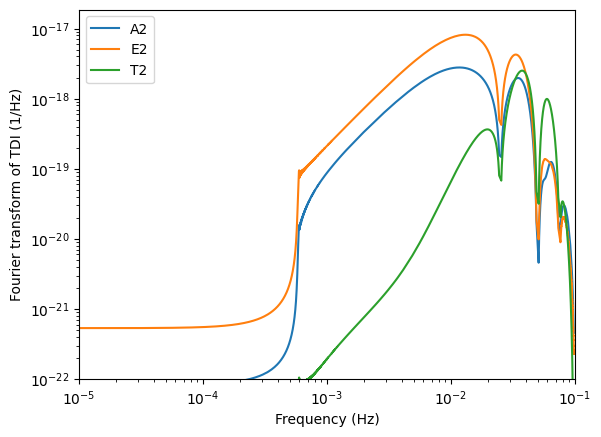

In [21]:
for ich, nch in enumerate(channel_names):
    plt.loglog(frequencies, np.abs(fd_waveform_from_td[ich]), label=nch)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Fourier transform of TDI (1/Hz)")
plt.legend(loc="upper left")
plt.xlim(1e-5, 0.1)
plt.ylim(1e-22,)

## Initialize frequency-domain template 

In [22]:
# initialize  waveform generator. we use the PhenomD waveform of WF4PY this time, and that of BBHx can be tested simillarly 
WFG = WaveformGenerator(mode="primary")

# initialize response generator 
FDTDI = FDTDIResponseGenerator(orbit_class=orbit, waveform_generator=WFG)

# response settings 
response_kwargs = dict(
    modes=[(2,2)], 
    tmin=tcb_times[0] / DAY,
    tmax=tcb_times[-1] / DAY, 
    TDIGeneration="2nd", # "1st" or "2nd"
    optimal_combination=True, # True for AET, False for XYZ 
)


## Generate frequency-domain template 

In [23]:
fd_waveform = FDTDI.Response(
    parameters=mbhb_parameters, 
    freqs=frequencies,  
    **response_kwargs, 
)

fd_waveform_from_td.shape, fd_waveform.shape 

((3, 119232), (3, 119232))

The amplitudes match well, but the phases generally donot match due to the difference between the implementations of Phenom waveform in different codes (``PyCBC`` vs ``WF4PY`` vs ``BBHx``).    
Perfect match can be achieved after optimizing over $\{t_c, \varphi_c\}$.     
See e.g. arXiv:2312.13039 for a similar discussion.   


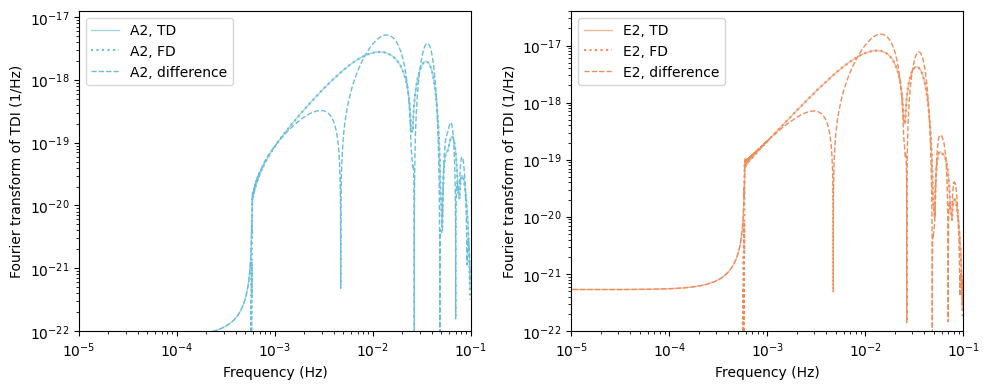

In [24]:
# plt.figure(figsize=(15, 4))
# for ich, nch, cch in zip(range(3), channel_names, [BLUE, ORANGE, GREEN1]):
plt.figure(figsize=(10, 4))
for ich, nch, cch in zip(range(2), channel_names[:2], [BLUE, ORANGE]):
    plt.subplot(121+ich)
    plt.loglog(frequencies, np.abs(fd_waveform_from_td[ich]), label=nch+", TD", color=cch, linewidth=1, alpha=0.6)
    plt.loglog(frequencies, np.abs(fd_waveform[ich]), label=nch+", FD", color=cch, linestyle=":")
    plt.loglog(frequencies, np.abs(fd_waveform_from_td[ich] - fd_waveform[ich]), label=nch+", difference", color=cch, linestyle="--", linewidth=1)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Fourier transform of TDI (1/Hz)")
    plt.legend(loc="upper left")
    plt.xlim(1e-5, 0.1)
    plt.ylim(1e-22,)
plt.tight_layout()

## Optimize 

In [25]:
PSDfunc = TDIPSDs() 
PSDdata = (PSDfunc.PSD_A2(frequencies))

def cost_function(param2d): 
    p = mbhb_parameters.copy() 
    p["coalescence_time"] = param2d[0]
    p["coalescence_phase"] = param2d[1]
    # p["psi"] = param2d[2]
    tmp = FDTDI.Response(p, frequencies, **response_kwargs)[:2] # use AE 
    return np.sum(np.abs(tmp - fd_waveform_from_td[:2]) ** 2 / PSDdata)

In [26]:
from scipy.optimize import differential_evolution

tc_range = 1e-2 * mbhb_parameters["chirp_mass"] / 1e6
result = differential_evolution(
    cost_function, 
    bounds=[(mbhb_parameters["coalescence_time"] - tc_range, mbhb_parameters["coalescence_time"] + tc_range), (0, TWOPI)],
    strategy='best1bin',    
    maxiter=5000,
    popsize=30,
    tol=1e-7, 
    mutation=(0.5, 1),    
    recombination=0.9, 
    workers=-1, 
    updating='deferred', 
    seed=42
)

print("differences between injection and optimized parameters:")
print("tc:", result.x[0] - mbhb_parameters["coalescence_time"])
print("phic:", result.x[1] - mbhb_parameters["coalescence_phase"])

differences between injection and optimized parameters:
tc: -0.0005321479010600427
phic: 0.4563405229124222


In [27]:
result

             message: Optimization terminated successfully.
             success: True
                 fun: 810639.4717690689
                   x: [ 1.200e+01  3.305e+00]
                 nit: 55
                nfev: 3420
          population: [[ 1.200e+01  3.305e+00]
                       [ 1.200e+01  3.305e+00]
                       ...
                       [ 1.200e+01  3.305e+00]
                       [ 1.200e+01  3.305e+00]]
 population_energies: [ 8.106e+05  8.106e+05 ...  8.106e+05  8.106e+05]

data SNR: 319.3204058696925
model SNR: 319.2599941221487
residual SNR: 1.5817628388287528
optimal mismatch: 1.225314598185534e-05


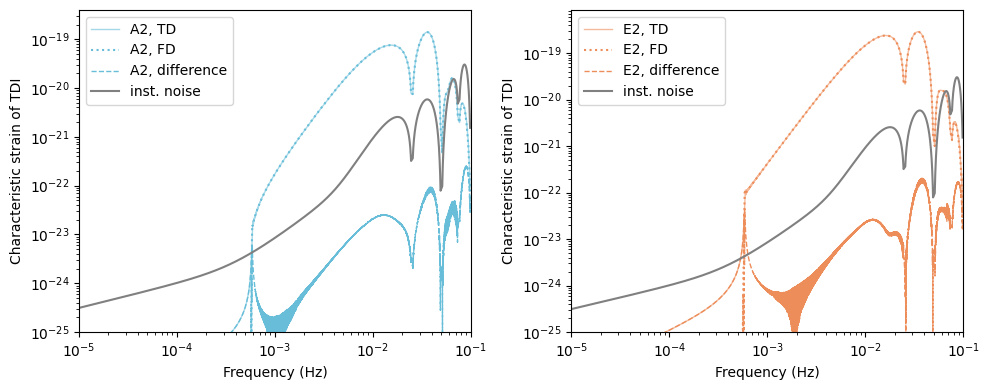

In [28]:
mbhb_parameters_opt = mbhb_parameters.copy()
mbhb_parameters_opt["coalescence_time"] = result.x[0]
mbhb_parameters_opt["coalescence_phase"] = result.x[1]

fd_waveform_opt = FDTDI.Response(
    parameters=mbhb_parameters_opt, 
    freqs=frequencies,  
    **response_kwargs, 
)

# plt.figure(figsize=(15, 4))
# for ich, nch, cch in zip(range(3), channel_names, [BLUE, ORANGE, GREEN1]):
plt.figure(figsize=(10, 4))
for ich, nch, cch in zip(range(2), channel_names[:2], [BLUE, ORANGE]):
    plt.subplot(121+ich)
    plt.loglog(frequencies, np.abs(fd_waveform_from_td[ich]) * 2. * frequencies, label=nch+", TD", color=cch, linewidth=1, alpha=0.6)
    plt.loglog(frequencies, np.abs(fd_waveform_opt[ich]) * 2. * frequencies, label=nch+", FD", color=cch, linestyle=":")
    plt.loglog(frequencies, np.abs(fd_waveform_from_td[ich] - fd_waveform_opt[ich]) * 2. * frequencies, label=nch+", difference", color=cch, linestyle="--", linewidth=1)
    plt.loglog(frequencies, np.sqrt(PSDdata * frequencies), color="grey", label="inst. noise")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Characteristic strain of TDI")
    plt.legend(loc="upper left")
    plt.xlim(1e-5, 0.1)
    plt.ylim(1e-25,)
plt.tight_layout() 


print("data SNR:", np.sqrt(4. / Tobs * np.sum(np.abs(fd_waveform_from_td[:2]) ** 2 / PSDdata)))
print("model SNR:", np.sqrt(4. / Tobs * np.sum(np.abs(fd_waveform_opt[:2]) ** 2 / PSDdata)))
print("residual SNR:", np.sqrt(4. / Tobs * np.sum(np.abs(fd_waveform_from_td[:2] - fd_waveform_opt[:2]) ** 2 / PSDdata)))

h1_h2_inner = np.sum(np.real(np.conjugate(fd_waveform_from_td[:2]) * fd_waveform_opt[:2]) / PSDdata)
h1_h1_inner = np.sum(np.abs(fd_waveform_from_td[:2]) ** 2 / PSDdata)
h2_h2_inner = np.sum(np.abs(fd_waveform_opt[:2]) ** 2 / PSDdata)
print("optimal mismatch:", 1. - h1_h2_inner / np.sqrt(h1_h1_inner * h2_h2_inner))